# Prediccion de Admision Universitaria con Regresion Logistica

---

**Autor:** Borja Mora Mendez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoria:** Machine Learning · Supervisado · Clasificacion · Regresion Logistica

---

### Objetivo

Construir un modelo de **Regresion Logistica** para predecir la admision universitaria a partir de horas de estudio y nota de examen. Con solo 2 features, podemos **visualizar la frontera de decision** — algo imposible en problemas con mas variables.

### Contexto de negocio

**El cliente:** departamento de admisiones de una universidad.

**El problema:** cada ciclo de admisiones llegan miles de solicitudes. El departamento quiere un sistema de scoring que estime la probabilidad de admision basandose en el expediente academico (horas de preparacion y nota de examen de acceso).

## 1️. Setup: librerías y configuración visual

In [ ]:
# Librerías base
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Modelado
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    accuracy_score,
)

# Estilo visual — sistema de color validado (consejo UX/UI Data)
BACKGROUND   = '#fbfbfb'
PURPLE       = '#7a7bff'   # único color de énfasis (1 por gráfico)
PURPLE_LIGHT = '#9b9cff'   # EDA de una sola serie (histogramas) -- PURPLE fuerte queda solo para el enfasis
POSITIVE     = '#6b8158'   # exclusivo signo positivo
NEGATIVE     = '#c34031'   # exclusivo signo negativo
NEUTRAL_BAR  = '#d9d9d9'   # barras/áreas de contexto (siempre con etiqueta de valor)
NEUTRAL_LINE = '#8f8c9e'   # líneas de contexto (más contraste que NEUTRAL_BAR)
CONTEXT_LINES = [NEUTRAL_LINE, '#a89a8a', '#7d94a8']   # gama fija para 2+ lineas de contexto en un mismo grafico
INK          = '#111111'
MUTED        = '#707070'

# Alias de compatibilidad con el resto del notebook
GREEN, RED, GRAY = POSITIVE, NEGATIVE, NEUTRAL_BAR

DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "borja_diverging", ["#c34031", "#e0a89f", "#f0ede8", "#b7c2a9", "#6b8158"]
)
SEQUENTIAL_GREEN = LinearSegmentedColormap.from_list(
    "borja_sequential", [BACKGROUND, POSITIVE]
)

def color_annotations(ax, values, threshold, dark="#ffffff", light=INK):
    """Recolorea el texto de un heatmap celda a celda según su magnitud."""
    for text, value in zip(ax.texts, np.asarray(values).flatten()):
        text.set_color(dark if abs(value) >= threshold else light)

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 100,
    'figure.facecolor': BACKGROUND,
    'axes.facecolor': BACKGROUND,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': MUTED,
    'axes.labelcolor': INK,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlecolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'font.family': 'sans-serif',
    'font.size': 10,
    'grid.color': '#f0f0f0',
    'grid.linewidth': 0.5,
})

## 2. Carga de datos

In [2]:
data = pd.read_excel("admitidos.xlsx")
print(f"Registros: {data.shape[0]} | Columnas: {data.shape[1]}")
data.head(10)

Registros: 1140 | Columnas: 3


,Horas_estudio,Nota_examen,Admitido
0,3,43.185412,0
1,7,50.346164,0
2,29,99.396287,1
3,13,68.363516,0
4,1,44.349536,0
5,20,77.713132,1
6,1,41.990022,0
7,2,45.948137,0
8,2,44.556393,0
9,1,42.297107,0


## 3. EDA: Análisis Exploratorio de datos

In [3]:
data.describe().round(2)

,Horas_estudio,Nota_examen,Admitido
count,1140.00,1140.00,1140.00
mean,9.98,59.93,0.23
std,8.93,18.03,0.42
min,0.00,35.14,0.00
25%,2.00,44.51,0.00
50%,7.00,55.35,0.00
75%,17.00,73.80,0.00
max,30.00,102.98,1.00


In [4]:
# Comprobar nulos y tipos

print('TIPOS DE DATOS Y VALORES NULOS')
print('─' * 70)
info = pd.DataFrame({
    'Tipo': data.dtypes,
    'Nulos': data.isnull().sum(),
    '% Nulos': (data.isnull().sum() / len(data) * 100).round(2),
    'Únicos': data.nunique()
})
info

TIPOS DE DATOS Y VALORES NULOS
──────────────────────────────────────────────────────────────────────


,Tipo,Nulos,% Nulos,Únicos
Horas_estudio,int64,0,0.0,31
Nota_examen,float64,0,0.0,1140
Admitido,int64,0,0.0,2


In [5]:
balance = data["Admitido"].value_counts(normalize=True)
print("Distribucion del target (Admitido):")
print(f"  No admitido (0): {balance[0]:.1%}")
print(f"  Admitido (1):    {balance[1]:.1%}")
print()

Distribucion del target (Admitido):
  No admitido (0): 76.8%
  Admitido (1):    23.2%



In [ ]:
# Distribuciones de cada variable

fig, axes = plt.subplots(3, 1, figsize=(13, 10))
fig.suptitle('Distribuciones de las variables', fontsize=14, fontweight='bold', color=INK, y=1.00)

variables = ["Horas_estudio", "Nota_examen", "Admitido"]
for ax, var in zip(axes.flat, variables):
    ax.hist(data[var], bins=20, color=PURPLE_LIGHT, edgecolor='white', alpha=0.85)
    ax.axvline(data[var].mean(), color=INK, linestyle='--', linewidth=1.5, label=f'Media: {data[var].mean():.1f}')
    ax.axvline(data[var].median(), color=NEUTRAL_LINE, linestyle='--', linewidth=1.5, label=f'Mediana: {data[var].median():.1f}')
    ax.set_title(var, color=INK)
    ax.legend(fontsize=9, frameon=False)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Matriz de correlación

cols_num = ["Horas_estudio", "Nota_examen", "Admitido"]

# Matriz de correlación
corr = data[cols_num].corr()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".4f",
    cmap=DIVERGING_CMAP,
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=2,
    linecolor=BACKGROUND,
    cbar_kws={"shrink": 0.75},
    annot_kws={"size": 10, "weight": "bold"},
)
color_annotations(ax, corr.values, threshold=0.8)

ax.set_title(
    "Matriz de correlación de Pearson",
    fontsize=14,
    fontweight="bold",
    color=INK,
    pad=18,
)

ax.tick_params(colors=INK)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Columna del target (`Admitido`)

- ``Horas_estudio``: **0.8224** → correlación fuerte y positiva.
- ``Nota_examen``: **0.8210** → correlación fuerte y positiva.

Entre variables predictoras

- ``Horas_estudio ↔ Nota_examen``: **0.9870** → correlación muy fuerte y positiva.

### Conclusión

La matriz de correlación muestra que tanto **las horas de estudio** como **la nota del examen** presentan una **fuerte relación positiva** con la admisión, lo que indica que ambas variables son buenos predictores del resultado.

Sin embargo, también existe una **correlación extremadamente alta (0.9870)** entre las dos variables predictoras. Esto sugiere la presencia de **multicolinealidad**, ya que ambas aportan prácticamente la misma información.

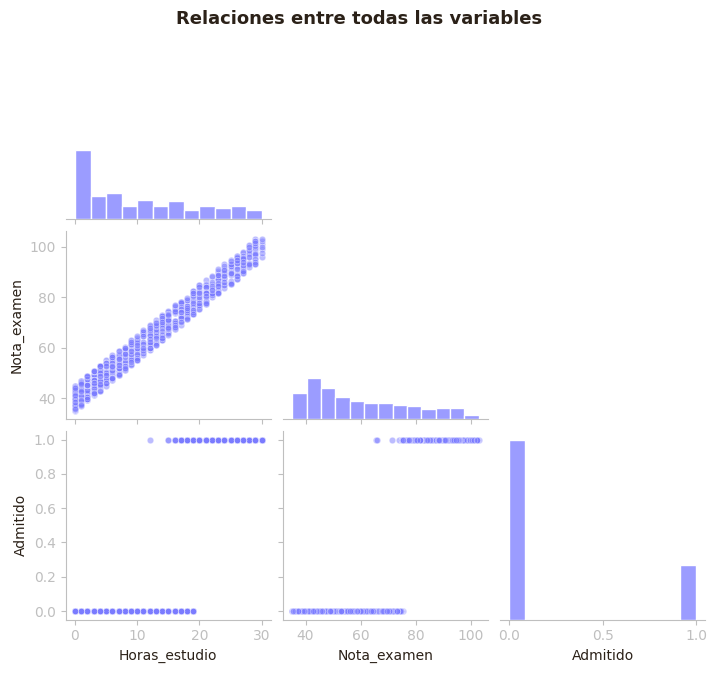

In [8]:
# Pair plot: relaciones por parejas
g = sns.pairplot(
    data[cols_num], height=2.2, aspect=1.1,
    plot_kws={'color': PURPLE, 'alpha': 0.5, 's': 22, 'edgecolor': 'white', 'linewidth': 0.5},
    diag_kws={'color': PURPLE, 'edgecolor': 'white'},
    corner=True
)
g.fig.suptitle('Relaciones entre todas las variables', y=1.01, fontsize=13, fontweight='bold', color=INK)
plt.show()

## 4. Train / Test Split


In [9]:
X = data[["Horas_estudio", "Nota_examen"]]
y = data["Admitido"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Tamaño train:", X_train.shape, "  Tamaño test:", X_test.shape)
print("─" * 50)
print("Balance en TRAIN:", round(y_train.mean() * 100, 1), "% admitidos")
print("Balance en TEST: ", round(y_test.mean() * 100, 1), "% admitidos")

Tamaño train: (855, 2)   Tamaño test: (285, 2)
──────────────────────────────────────────────────
Balance en TRAIN: 23.3 % admitidos
Balance en TEST:  23.2 % admitidos


## 5. Modelo estadistico — `statsmodels.Logit`

Primero statsmodels para p-valores, luego sklearn para prediccion y frontera.

In [10]:
X_train_sm = sm.add_constant(X_train).astype(float)
X_test_sm = sm.add_constant(X_test).astype(float)

modelo_logit = sm.Logit(y_train, X_train_sm).fit(disp=0)
print(modelo_logit.summary())

                           Logit Regression Results                           
Dep. Variable:               Admitido   No. Observations:                  855
Model:                          Logit   Df Residuals:                      852
Method:                           MLE   Df Model:                            2
Date:                Fri, 14 Aug 2026   Pseudo R-squ.:                  0.9205
Time:                        18:47:41   Log-Likelihood:                -36.889
converged:                       True   LL-Null:                       -463.90
Covariance Type:            nonrobust   LLR p-value:                3.553e-186
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const           -60.8436     11.935     -5.098      0.000     -84.237     -37.451
Horas_estudio     0.2127      0.208      1.022      0.307      -0.195       0.621
Nota_examen       0.7586      0.180     

### Conclusiones

- ``Horas_estudio``: coeficiente positivo (**0.2127**), pero **no significativo** (p = 0.307).
- ``Nota_examen``: coeficiente positivo (**0.7586**) y **estadísticamente significativo** (p < 0.001).


In [11]:
# Cálculo del VIF para cada predictora (excluyendo la constante)
X_vif = X_train.astype(float)
vif = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
}).sort_values("VIF", ascending=False)

vif.round(2)

,Variable,VIF
0,Horas_estudio,5.41
1,Nota_examen,5.41


Los resultados nos indican que no hay multicolinealidad entre las dos variables predictoras. 

## 6.Evaluación con métricas de clasificación

In [12]:
# Probabilidades predichas en el test set
y_pred_sm = modelo_logit.predict(X_test_sm)

# Clasificación con threshold por defecto = 0.5
y_sm = (y_pred_sm >= 0.5).astype(int)

print("Primeras 10 probabilidades predichas:")
print(y_pred_sm.head(10).round(3).values)

Primeras 10 probabilidades predichas:
[0.    0.    0.    1.    0.    0.995 1.    0.    0.001 0.   ]


In [13]:
#Matriz de confusión

cm = confusion_matrix(y_test, y_sm)
tn, fp, fn, tp = cm.ravel()

print("─" * 50)
print("MATRIZ DE CONFUSIÓN (threshold = 0.5)")
print("─" * 50)
print("                  Predicho 0    Predicho 1")
print("Real 0           ", str(tn).rjust(10), str(fp).rjust(14))
print("Real 1           ", str(fn).rjust(10), str(tp).rjust(14))
print()
print("TN (aciertos en 0):", tn)
print("FP (falsa alarma): ", fp)
print("FN (no detectado): ", fn)
print("TP (acierto en 1): ", tp)

──────────────────────────────────────────────────
MATRIZ DE CONFUSIÓN (threshold = 0.5)
──────────────────────────────────────────────────
                  Predicho 0    Predicho 1
Real 0                   219              0
Real 1                     2             64

TN (aciertos en 0): 219
FP (falsa alarma):  0
FN (no detectado):  2
TP (acierto en 1):  64


#### Matriz de confusión

La matriz de confusión muestra un rendimiento prácticamente perfecto del modelo:

- **219** candidatos **no admitidos** fueron clasificados correctamente.
- **64** candidatos **admitidos** fueron clasificados correctamente.
- **0** candidatos **no admitidos** fueron clasificados erróneamente como admitidos (*falsos positivos*).
- **2** candidatos **admitidos** fueron clasificados como no admitidos (*falsos negativos*).

#### Conclusión

El modelo clasifica correctamente **283 de los 285 candidatos**, cometiendo únicamente **2 errores**. Además, no genera **falsos positivos**, lo que significa que **ningún candidato no admitido sería aceptado por error**, ofreciendo una clasificación muy fiable.

In [14]:
# Sklearn ofrece el reporte completo
print(classification_report(y_test, y_sm, target_names=["No admitido", "Admitido"]))

              precision    recall  f1-score   support

 No admitido       0.99      1.00      1.00       219
    Admitido       1.00      0.97      0.98        66

    accuracy                           0.99       285
   macro avg       1.00      0.98      0.99       285
weighted avg       0.99      0.99      0.99       285



In [15]:
# Cálculo de la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_sm)
auc = roc_auc_score(y_test, y_pred_sm)

print("AUC =", round(auc, 4))

AUC = 0.9992


In [ ]:
# Visualización de la curva ROC
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr, tpr, color=PURPLE, linewidth=2.5, label=f"Modelo (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], color=INK, linestyle="--", linewidth=1.5, label="Modelo aleatorio (AUC = 0.5)")

ax.fill_between(fpr, tpr, alpha=0.1, color=PURPLE)

ax.set_xlabel("Tasa de Falsos Positivos (FPR)")
ax.set_ylabel("Tasa de Verdaderos Positivos (TPR / Recall)")
ax.set_title("Curva ROC", fontsize=13, weight="bold")
ax.legend(loc="lower right", frameon=False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Curva ROC

El modelo obtiene un **AUC-ROC de 0.9992**, un valor prácticamente perfecto. Esto indica que la Regresión Logística distingue con gran precisión entre candidatos admitidos y no admitidos, independientemente del umbral de clasificación utilizado.

### Odds Ratios

In [17]:
coefs = modelo_logit.params
conf = modelo_logit.conf_int()
conf.columns = ["IC 2.5%", "IC 97.5%"]

tabla_or = pd.DataFrame({
    "Coeficiente": coefs,
    "Odds Ratio": np.exp(coefs),
    "IC 2.5%": np.exp(conf["IC 2.5%"]),
    "IC 97.5%": np.exp(conf["IC 97.5%"]),
    "P-valor": modelo_logit.pvalues,
}).round(4)

print("Odds Ratios con intervalos de confianza:")
print(tabla_or.to_string())
print()
for var in ["Horas_estudio", "Nota_examen"]:
    or_val = tabla_or.loc[var, "Odds Ratio"]


Odds Ratios con intervalos de confianza:
               Coeficiente  Odds Ratio  IC 2.5%  IC 97.5%  P-valor
const             -60.8436      0.0000   0.0000    0.0000   0.0000
Horas_estudio       0.2127      1.2370   0.8226    1.8601   0.3069
Nota_examen         0.7586      2.1353   1.5011    3.0373   0.0000



#### Odds Ratio

Los **Odds Ratio** indican cómo cambia la probabilidad de admisión al aumentar una unidad cada variable, manteniendo el resto constantes.

- ``Horas_estudio``: **OR = 1.237** → aumentar una hora de estudio incrementa las probabilidades de admisión un **23,7%**, aunque este efecto **no es estadísticamente significativo** (p = 0.307).

- ``Nota_examen``: **OR = 2.135** → aumentar un punto en la nota multiplica por **2,14** las probabilidades de ser admitido. Además, este efecto es **estadísticamente significativo** (p < 0.001).


In [ ]:
# Visualización de los Odds Ratios
fig, ax = plt.subplots(figsize=(9, 5))

tabla_plot = tabla_or.drop("const", errors="ignore").copy()
tabla_plot = tabla_plot.sort_values("Odds Ratio")

colores = [POSITIVE if v > 1 else NEGATIVE for v in tabla_plot["Odds Ratio"]]

ax.barh(tabla_plot.index, tabla_plot["Odds Ratio"], color=colores, alpha=0.85)
ax.axvline(1, color=INK, linestyle="--", linewidth=1)

ax.set_xlabel("Odds Ratio")
ax.set_title("Impacto de cada variable sobre las odds de conversión", fontsize=13, weight="bold")

for i, v in enumerate(tabla_plot["Odds Ratio"]):
    ax.text(v + 0.05, i, f"{v:.2f}", va="center", fontsize=10, color=INK)

plt.tight_layout()
plt.show()

# Insights de negocio

La **nota del examen** es el principal factor que determina la probabilidad de admisión. Aunque las **horas de estudio** están fuertemente relacionadas con el resultado, una vez conocida la nota su contribución deja de ser significativa. El modelo clasifica correctamente el **99% de los candidatos** y alcanza un **AUC-ROC de 0.999**, mostrando una capacidad de discriminación prácticamente perfecta.

